<a href="https://colab.research.google.com/github/KhizraKhan725/Khizra-Projects/blob/main/AI2002_A6_Q6_WumpusAgent_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import copy
import itertools
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("All imports successful.")
print(" Modules: random, copy, itertools, matplotlib, numpy")

All imports successful.
 Modules: random, copy, itertools, matplotlib, numpy


In [ ]:
class PropLogicKB:
    """
    Propositional Logic Knowledge Base using CNF clauses.
    Supports TELL (add clause) and ASK (resolution refutation query).
    """

    def __init__(self):
        self.clauses = set()
        self.inference_steps = 0
        self.proof_log = []

    # ── TELL ──────────────────────────────────────────────
    def tell(self, clause: list):
        """Add a CNF clause (list of literals) to the KB."""
        fc = frozenset(clause)
        if fc not in self.clauses:
            self.clauses.add(fc)

    def tell_breeze(self, r, c, adjacents):
        """
        Breeze at (r,c) means at least one adjacent cell has a pit.
        CNF of: B_{r,c} <=> (P_{adj1} v P_{adj2} v ...)
        Forward  : -B v P_adj1 v P_adj2 v ...
        Backward : -P_adji v B   (for each adjacent i)
        Since B is True (we perceived it), substitute and simplify.
        """
        b = f'B_{r}_{c}'
        self.tell([b])
        pit_lits = [f'P_{ar}_{ac}' for ar, ac in adjacents]
        self.tell([f'-{b}'] + pit_lits)
        for ar, ac in adjacents:
            self.tell([f'-P_{ar}_{ac}', b])

    def tell_no_breeze(self, r, c, adjacents):
        """No breeze => no pits in any adjacent cell."""
        nb = f'-B_{r}_{c}'
        self.tell([nb])
        for ar, ac in adjacents:
            self.tell([f'-P_{ar}_{ac}'])

    def tell_stench(self, r, c, adjacents):
        """Stench <=> at least one adjacent cell has Wumpus."""
        s = f'S_{r}_{c}'
        self.tell([s])
        wump_lits = [f'W_{ar}_{ac}' for ar, ac in adjacents]
        self.tell([f'-{s}'] + wump_lits)
        for ar, ac in adjacents:
            self.tell([f'-W_{ar}_{ac}', s])

    def tell_no_stench(self, r, c, adjacents):
        """No stench => no Wumpus in any adjacent cell."""
        self.tell([f'-S_{r}_{c}'])
        for ar, ac in adjacents:
            self.tell([f'-W_{ar}_{ac}'])

    def ask(self, goal_literal: str, max_steps: int = 800):
        """
        Prove `goal_literal` by Resolution Refutation:
        1. Negate the goal and add to KB copy.
        2. Repeatedly resolve pairs of clauses.
        3. If empty clause ⊥ is derived → goal is PROVED.
        4. If no new clauses can be derived → goal is UNPROVABLE.

        Returns: dict with 'proved' (bool), 'steps' (int), 'log' (list)
        """
        self.proof_log = []

        neg_goal = goal_literal[1:] if goal_literal.startswith('-') else f'-{goal_literal}'
        neg_clause = frozenset([neg_goal])

        working = list(self.clauses) + [neg_clause]
        seen = set(working)
        steps = 0

        self.proof_log.append(f"Goal: prove [{goal_literal}]")
        self.proof_log.append(f"Negated goal clause: {{{neg_goal}}}")
        self.proof_log.append(f"Starting KB size: {len(working)} clauses")

        queue = list(working)
        i = 0
        while i < len(queue) and steps < max_steps:
            ci = queue[i]
            for j in range(len(queue)):
                if i == j:
                    continue
                cj = queue[j]
                steps += 1
                self.inference_steps += 1
                resolvent = self._resolve(ci, cj)
                if resolvent is None:
                    continue
                if len(resolvent) == 0:
                    self.proof_log.append(f"Step {steps}: CONTRADICTION ⊥ derived from {set(ci)} and {set(cj)}")
                    return {'proved': True, 'steps': steps, 'log': self.proof_log}
                if resolvent not in seen:
                    seen.add(resolvent)
                    queue.append(resolvent)
            i += 1

        self.proof_log.append(f"No contradiction found after {steps} steps.")
        return {'proved': False, 'steps': steps, 'log': self.proof_log}

    def _resolve(self, c1: frozenset, c2: frozenset):
        """
        Resolution Rule:
        Given two clauses c1 and c2, if c1 contains literal L
        and c2 contains ¬L, produce the resolvent:
          (c1 \ {L}) ∪ (c2 \ {¬L})
        Returns None if no complementary literal found or result is a tautology.
        """
        for lit in c1:
            neg = lit[1:] if lit.startswith('-') else f'-{lit}'
            if neg in c2:
                result = (c1 - {lit}) | (c2 - {neg})

                for l in result:
                    n = l[1:] if l.startswith('-') else f'-{l}'
                    if n in result:
                        return None
                return frozenset(result)
        return None

    def __repr__(self):
        return f"PropLogicKB({len(self.clauses)} clauses, {self.inference_steps} inference steps)"


print("=" * 55)
print("  Unit Test: PropLogicKB Resolution")
print("=" * 55)
test_kb = PropLogicKB()
test_kb.tell(['A', 'B'])
test_kb.tell(['-A', 'C'])
test_kb.tell(['-B', 'C'])
result = test_kb.ask('C')
print(f"  KB: (A∨B) ∧ (¬A∨C) ∧ (¬B∨C)")
print(f"  ASK(C) → Proved: {result['proved']} | Steps: {result['steps']}")
assert result['proved'], "Resolution test failed!"
print("  PASSED\n")

test_kb2 = PropLogicKB()
test_kb2.tell(['P'])
test_kb2.tell(['-P'])
r2 = test_kb2.ask('Q')
print(f"  KB: P ∧ ¬P  →  ASK(Q) = {r2['proved']}  (should be True, ex-falso)")
print("  PASSED")

  Unit Test: PropLogicKB Resolution
  KB: (A∨B) ∧ (¬A∨C) ∧ (¬B∨C)
  ASK(C) → Proved: True | Steps: 24
  PASSED

  KB: P ∧ ¬P  →  ASK(Q) = True  (should be True, ex-falso)
  PASSED


In [ ]:
class WumpusWorld:
    """
    Wumpus World grid environment.
    Grid cells are indexed (row, col) starting at (0,0) = bottom-left (agent start).
    """

    EMPTY   = 0
    PIT     = 1
    WUMPUS  = 2

    def __init__(self, rows: int = 4, cols: int = 4, num_pits: int = 3, seed: int = None):
        self.rows = rows
        self.cols = cols
        self.num_pits = num_pits
        if seed is not None:
            random.seed(seed)
        self.grid = [[self.EMPTY] * cols for _ in range(rows)]
        self._place_hazards()

    def _place_hazards(self):
        """Randomly place pits and wumpus (never at start cell 0,0)."""
        all_cells = [(r, c) for r in range(self.rows)
                             for c in range(self.cols)
                             if not (r == 0 and c == 0)]
        random.shuffle(all_cells)

        pit_cells = all_cells[:self.num_pits]
        for r, c in pit_cells:
            self.grid[r][c] = self.PIT

        wumpus_cell = all_cells[self.num_pits]
        self.grid[wumpus_cell[0]][wumpus_cell[1]] = self.WUMPUS
        self.wumpus_pos = wumpus_cell

    def get_adjacent(self, r: int, c: int):
        """Return valid orthogonal neighbours of (r, c)."""
        return [(r+dr, c+dc)
                for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]
                if 0 <= r+dr < self.rows and 0 <= c+dc < self.cols]

    def get_percepts(self, r: int, c: int):
        """
        Returns percepts at cell (r, c):
          breeze  = True if any adjacent cell has a Pit
          stench  = True if any adjacent cell has the Wumpus
        """
        adj = self.get_adjacent(r, c)
        breeze = any(self.grid[ar][ac] == self.PIT    for ar, ac in adj)
        stench = any(self.grid[ar][ac] == self.WUMPUS for ar, ac in adj)
        return {'breeze': breeze, 'stench': stench}

    def is_deadly(self, r: int, c: int):
        return self.grid[r][c] in (self.PIT, self.WUMPUS)

    def display(self, reveal=False):
        """Print ASCII art of the world."""
        symbols = {self.EMPTY: '.', self.PIT: 'P', self.WUMPUS: 'W'}
        print(f"  World ({self.rows}x{self.cols}) | Pits={self.num_pits}")
        print("  " + "+----" * self.cols + "+")
        for r in range(self.rows - 1, -1, -1):
            row_str = "  |"
            for c in range(self.cols):
                cell = self.grid[r][c]
                if reveal:
                    row_str += f" {symbols[cell]:2} |"
                else:
                    row_str += "  ? |"
            print(row_str)
            print("  " + "+----" * self.cols + "+")

print("=" * 45)
print("  Demo: Wumpus World (4x4, revealed)")
print("=" * 45)
demo_world = WumpusWorld(rows=4, cols=4, num_pits=3, seed=42)
demo_world.display(reveal=True)
print(f"  Wumpus at: {demo_world.wumpus_pos}")
print(f"  Percepts at (0,0): {demo_world.get_percepts(0,0)}")

  Demo: Wumpus World (4x4, revealed)
  World (4x4) | Pits=3
  +----+----+----+----+
  | .  | .  | P  | .  |
  +----+----+----+----+
  | P  | P  | .  | .  |
  +----+----+----+----+
  | .  | .  | .  | W  |
  +----+----+----+----+
  | .  | .  | .  | .  |
  +----+----+----+----+
  Wumpus at: (1, 3)
  Percepts at (0,0): {'breeze': False, 'stench': False}


In [ ]:
class WumpusAgent:
    """
    Knowledge-Based Agent for the Wumpus World.
    Uses PropLogicKB + Resolution Refutation to make safe movement decisions.
    """

    def __init__(self, world: WumpusWorld):
        self.world   = world
        self.kb      = PropLogicKB()
        self.pos     = (0, 0)
        self.visited = set()
        self.safe    = set()
        self.unsafe  = set()
        self.alive   = True
        self.won     = False
        self.history = []
        self.step_log = []

        # Start cell is always safe
        self.kb.tell(['-P_0_0'])
        self.kb.tell(['-W_0_0'])
        self.safe.add((0, 0))
        self._visit(0, 0)

    def _visit(self, r, c):
        """Visit cell (r,c): get percepts, TELL KB, update safe set."""
        self.pos = (r, c)
        self.visited.add((r, c))
        self.safe.add((r, c))

        percepts = self.world.get_percepts(r, c)
        adj = self.world.get_adjacent(r, c)

        if percepts['breeze']:
            self.kb.tell_breeze(r, c, adj)
            self.step_log.append(f"  [TELL] Breeze at ({r},{c}) → pit possible in {adj}")
        else:
            self.kb.tell_no_breeze(r, c, adj)
            self.step_log.append(f"  [TELL] No breeze at ({r},{c}) → {adj} are pit-free")

        if percepts['stench']:
            self.kb.tell_stench(r, c, adj)
            self.step_log.append(f"  [TELL] Stench at ({r},{c}) → Wumpus possible in {adj}")
        else:
            self.kb.tell_no_stench(r, c, adj)
            self.step_log.append(f"  [TELL] No stench at ({r},{c}) → {adj} are Wumpus-free")

        self._run_inference()
        return percepts

    def _run_inference(self):
        """ASK the KB whether each unvisited adjacent cell is safe."""
        for r in range(self.world.rows):
            for c in range(self.world.cols):
                if (r, c) in self.visited:
                    continue
                no_pit   = self.kb.ask(f'-P_{r}_{c}')['proved']
                no_wump  = self.kb.ask(f'-W_{r}_{c}')['proved']
                has_pit  = self.kb.ask(f'P_{r}_{c}')['proved']
                has_wump = self.kb.ask(f'W_{r}_{c}')['proved']
                if no_pit and no_wump:
                    if (r, c) not in self.safe:
                        self.safe.add((r, c))
                        self.step_log.append(f"  [ASK]  ({r},{c}) proven SAFE by Resolution")
                if has_pit or has_wump:
                    self.unsafe.add((r, c))

    def choose_next(self):
        """
        Decision logic:
        1. Move to an unvisited KB-proven safe neighbour.
        2. If none, move to any unvisited safe cell reachable.
        3. If none, move to an unknown (not proven dangerous) cell.
        """
        r, c = self.pos
        adj = self.world.get_adjacent(r, c)

        safe_adj = [(ar, ac) for ar, ac in adj
                    if (ar, ac) not in self.visited and (ar, ac) in self.safe]
        if safe_adj:
            return random.choice(safe_adj), 'safe-adjacent'

        safe_any = [(sr, sc) for sr, sc in self.safe
                    if (sr, sc) not in self.visited]
        if safe_any:

            target = min(safe_any, key=lambda x: abs(x[0]-r)+abs(x[1]-c))

            next_step = self._bfs_step(self.pos, target)
            if next_step:
                return next_step, 'safe-bfs'

        unknown_adj = [(ar, ac) for ar, ac in adj
                       if (ar, ac) not in self.visited and (ar, ac) not in self.unsafe]
        if unknown_adj:
            return random.choice(unknown_adj), 'unknown-risk'

        return None, 'stuck'

    def _bfs_step(self, start, goal):
        """BFS to find first step from start toward goal (through visited/safe cells)."""
        from collections import deque
        queue = deque([[start]])
        visited_bfs = {start}
        while queue:
            path = queue.popleft()
            cur = path[-1]
            if cur == goal:
                return path[1] if len(path) > 1 else None
            for nb in self.world.get_adjacent(cur[0], cur[1]):
                if nb not in visited_bfs and (nb in self.visited or nb in self.safe):
                    visited_bfs.add(nb)
                    queue.append(path + [nb])
        return None

    def step(self):
        """Execute one agent step. Returns True if game continues."""
        if not self.alive or self.won:
            return False

        next_pos, reason = self.choose_next()
        if next_pos is None:
            self.step_log.append("  [AGENT] No valid move — agent is stuck.")
            return False

        r, c = next_pos
        self.step_log.append(f"\n→ Moving to ({r},{c}) [strategy: {reason}]")
        percepts = self._visit(r, c)

        if self.world.is_deadly(r, c):
            cell_type = "Pit" if self.world.grid[r][c] == WumpusWorld.PIT else "Wumpus"
            self.step_log.append(f"  [DEAD] Agent entered {cell_type} at ({r},{c})!")
            self.alive = False
            return False

        total_safe_cells = sum(1 for rr in range(self.world.rows)
                                 for cc in range(self.world.cols)
                                 if self.world.grid[rr][cc] == WumpusWorld.EMPTY)
        if len(self.visited) >= total_safe_cells:
            self.won = True
            self.step_log.append("  [WON]  All safe cells explored!")
            return False

        return True


print(" WumpusAgent class defined.")

 WumpusAgent class defined.


In [ ]:
def plot_world_state(world: WumpusWorld, agent: WumpusAgent,
                     title: str = "", reveal: bool = False):
    """
    Render the Wumpus World grid with color-coded cell states.

    Color Legend:
      Blue        = Agent current position
      Dark Green  = Visited safe cell
      Light Green = KB-inferred safe (unvisited)
      Gray        = Unknown (not yet reasoned about)
      Orange-Red  = KB-inferred dangerous
      Red         = Pit (revealed)
      Purple      = Wumpus (revealed)
    """
    rows, cols = world.rows, world.cols
    fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                              gridspec_kw={'width_ratios': [2, 1]})
    ax = axes[0]

    color_grid = np.zeros((rows, cols, 3))
    cell_text  = [[""] * cols for _ in range(rows)]

    COLOR = {
        'agent':    np.array([0.13, 0.47, 0.85]),
        'visited':  np.array([0.18, 0.55, 0.34]),
        'safe':     np.array([0.72, 0.93, 0.76]),
        'unknown':  np.array([0.85, 0.85, 0.88]),
        'unsafe':   np.array([0.95, 0.55, 0.33]),
        'pit':      np.array([0.85, 0.15, 0.15]),
        'wumpus':   np.array([0.55, 0.18, 0.75]),
    }

    for r in range(rows):
        for c in range(cols):
            key = 'unknown'
            label = '?'

            if reveal:
                if world.grid[r][c] == WumpusWorld.PIT:
                    key, label = 'pit', ' PIT'
                elif world.grid[r][c] == WumpusWorld.WUMPUS:
                    key, label = 'wumpus', ' W'

            if (r, c) == agent.pos:
                key, label = 'agent', ''
            elif (r, c) in agent.visited:
                key = 'visited'
                perc = world.get_percepts(r, c)
                parts = []
                if perc['breeze']:  parts.append('💨')
                if perc['stench']: parts.append('🦨')
                label = '\n'.join(parts) if parts else '✓'
            elif (r, c) in agent.safe:
                key, label = 'safe', ' Safe'
            elif (r, c) in agent.unsafe:
                key, label = 'unsafe', '⚠ Danger'

            color_grid[rows - 1 - r, c] = COLOR[key]
            cell_text[rows - 1 - r][c] = label

    ax.imshow(color_grid, aspect='equal', interpolation='nearest')

    for r in range(rows):
        for c in range(cols):
            txt = cell_text[r][c]
            ax.text(c, r, txt, ha='center', va='center',
                    fontsize=11, fontweight='bold',
                    color='white' if color_grid[r,c].mean() < 0.5 else '#333')
            ax.text(c + 0.45, r + 0.45,
                    f"({rows-1-r},{c})",
                    ha='right', va='bottom', fontsize=7, color='#666')

    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=2)
    ax.tick_params(which='both', bottom=False, left=False,
                   labelbottom=False, labelleft=False)
    ax.set_title(title or f"Wumpus World — Step {len(agent.visited)-1}",
                 fontsize=13, fontweight='bold', pad=10)

    legend_items = [
        (COLOR['agent'],   ' Agent'),
        (COLOR['visited'], 'Visited'),
        (COLOR['safe'],    ' KB-Safe (Inferred)'),
        (COLOR['unknown'], ' Unknown'),
        (COLOR['unsafe'],  ' KB-Dangerous'),
        (COLOR['pit'],     ' Pit (revealed)'),
        (COLOR['wumpus'],  ' Wumpus (revealed)'),
    ]
    handles = [mpatches.Patch(facecolor=col, label=lbl,
                              edgecolor='#aaa', linewidth=0.5)
               for col, lbl in legend_items]
    ax.legend(handles=handles, loc='upper right',
              bbox_to_anchor=(1.0, -0.02), fontsize=9,
              framealpha=0.9, ncol=2)

    ax2 = axes[1]
    ax2.axis('off')
    metrics = [
        ("Grid Size",           f"{world.rows} × {world.cols}"),
        ("Total Pits",          str(world.num_pits)),
        ("Agent Position",      str(agent.pos)),
        ("Cells Visited",       str(len(agent.visited))),
        ("KB-Safe Cells",       str(len(agent.safe))),
        ("KB-Dangerous Cells",  str(len(agent.unsafe))),
        ("KB Clauses",          str(len(agent.kb.clauses))),
        ("Inference Steps",     str(agent.kb.inference_steps)),
        ("Agent Status",        "ALIVE " if agent.alive else ("WON " if agent.won else "DEAD ")),
    ]
    y = 0.95
    ax2.text(0.05, y, " Real-Time Metrics", transform=ax2.transAxes,
             fontsize=13, fontweight='bold', va='top', color='#1a1a2e')
    y -= 0.08
    ax2.plot([0.05, 0.95], [y, y], color='#ccc', linewidth=1, transform=ax2.transAxes, clip_on=False)
    y -= 0.02
    for label, value in metrics:
        ax2.text(0.05, y, label + ":", transform=ax2.transAxes,
                 fontsize=10, va='top', color='#555', fontstyle='italic')
        ax2.text(0.60, y, value, transform=ax2.transAxes,
                 fontsize=10, va='top', color='#111', fontweight='bold')
        y -= 0.09

    plt.tight_layout()
    plt.show()


print("✅ Visualization functions ready.")

✅ Visualization functions ready.


---
## Cell 6 — Run Simulation (Step-by-Step)

Run the agent on a **4×4** world and visualize each step.  
The KB is printed at each step to show which clauses were added.

  Wumpus World Simulation  (4×4)  seed=99

  TRUE world (revealed for reference):
  World (4x4) | Pits=3
  +----+----+----+----+
  | .  | .  | .  | .  |
  +----+----+----+----+
  | .  | W  | .  | .  |
  +----+----+----+----+
  | .  | P  | P  | .  |
  +----+----+----+----+
  | .  | .  | P  | .  |
  +----+----+----+----+
  Wumpus at: (2, 1)


─── Step 0 (Start) ─────────────────────────────────


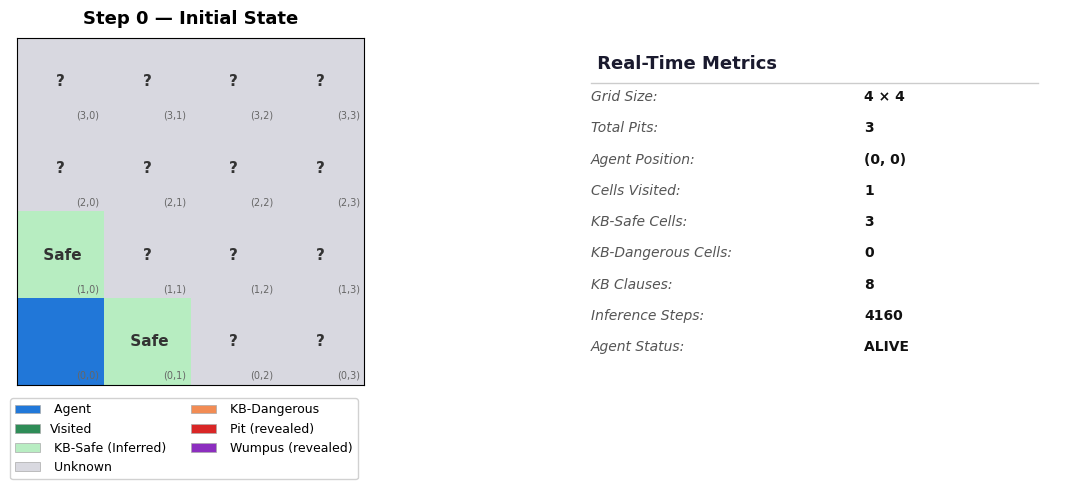


─── Step 1 ─────────────────────────────────────
  [TELL] No breeze at (0,0) → [(1, 0), (0, 1)] are pit-free
  [TELL] No stench at (0,0) → [(1, 0), (0, 1)] are Wumpus-free
  [ASK]  (0,1) proven SAFE by Resolution
  [ASK]  (1,0) proven SAFE by Resolution

→ Moving to (0,1) [strategy: safe-adjacent]
  [TELL] Breeze at (0,1) → pit possible in [(1, 1), (0, 0), (0, 2)]
  [TELL] No stench at (0,1) → [(1, 1), (0, 0), (0, 2)] are Wumpus-free


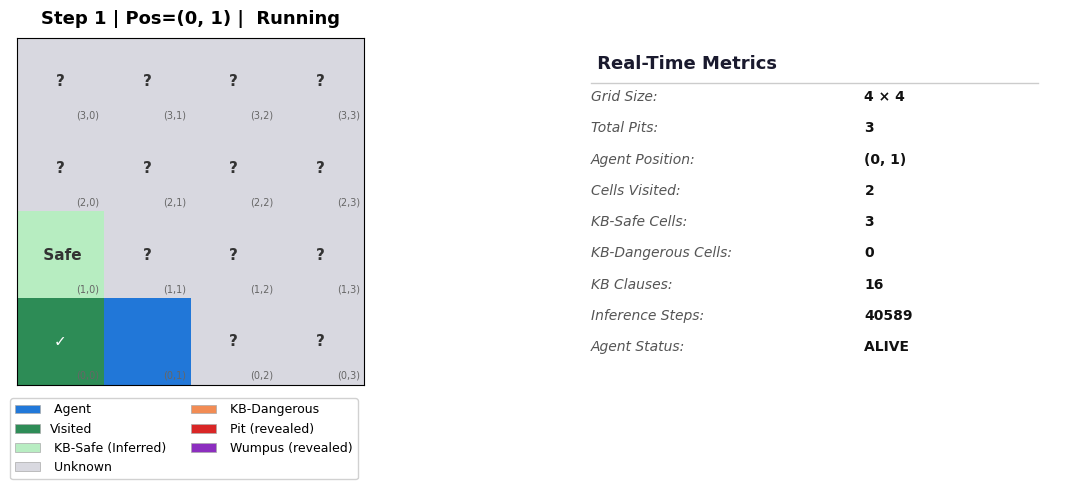


─── Step 2 ─────────────────────────────────────

→ Moving to (0,0) [strategy: safe-bfs]
  [TELL] No breeze at (0,0) → [(1, 0), (0, 1)] are pit-free
  [TELL] No stench at (0,0) → [(1, 0), (0, 1)] are Wumpus-free


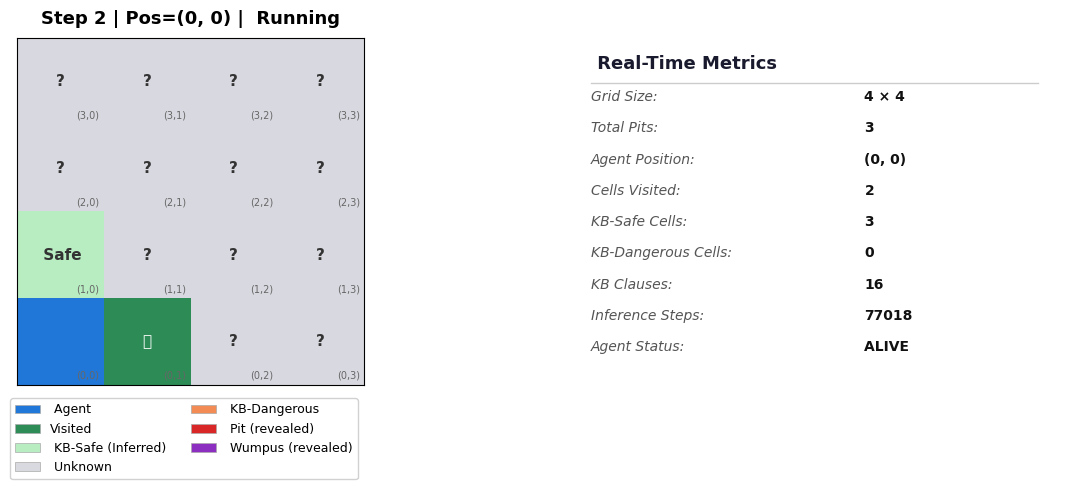


─── Step 3 ─────────────────────────────────────

→ Moving to (1,0) [strategy: safe-adjacent]
  [TELL] Breeze at (1,0) → pit possible in [(0, 0), (2, 0), (1, 1)]
  [TELL] No stench at (1,0) → [(0, 0), (2, 0), (1, 1)] are Wumpus-free


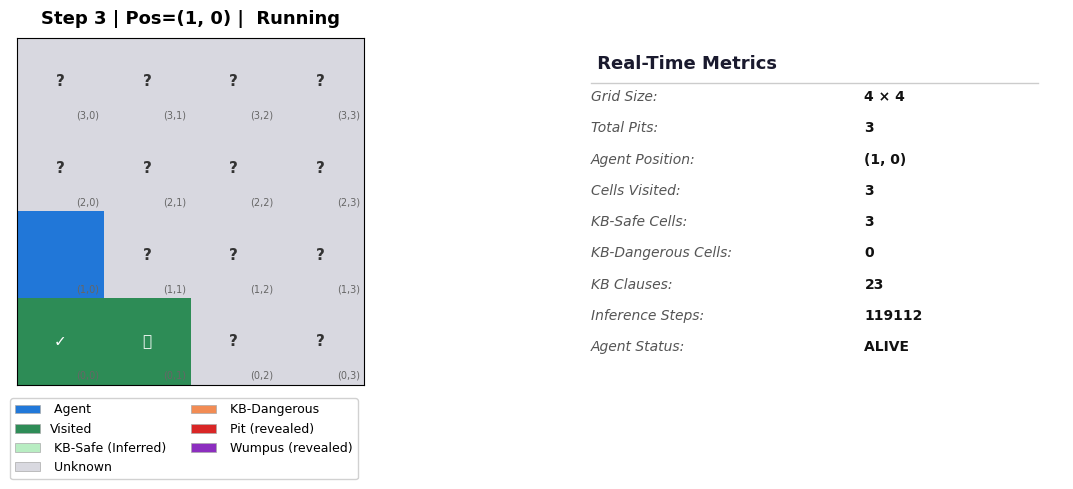


─── Step 4 ─────────────────────────────────────

→ Moving to (1,1) [strategy: unknown-risk]
  [TELL] Breeze at (1,1) → pit possible in [(0, 1), (2, 1), (1, 0), (1, 2)]
  [TELL] Stench at (1,1) → Wumpus possible in [(0, 1), (2, 1), (1, 0), (1, 2)]
  [DEAD] Agent entered Pit at (1,1)!


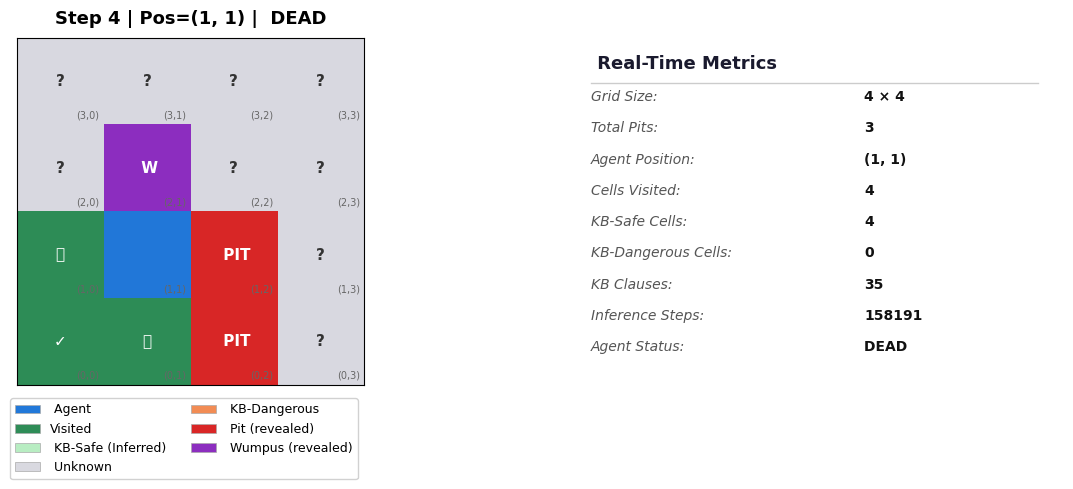


   AGENT DIED — Entered a hazardous cell.
  Total Inference Steps : 158191
  Total KB Clauses      : 35
  Cells Visited         : 4


In [ ]:

ROWS       = 4
COLS       = 4
NUM_PITS   = 3
SEED       = 99
MAX_STEPS  = 20
REVEAL     = False


print("=" * 60)
print(f"  Wumpus World Simulation  ({ROWS}×{COLS})  seed={SEED}")
print("=" * 60)

world = WumpusWorld(rows=ROWS, cols=COLS, num_pits=NUM_PITS, seed=SEED)
agent = WumpusAgent(world)

print("\n  TRUE world (revealed for reference):")
world.display(reveal=True)
print(f"  Wumpus at: {world.wumpus_pos}\n")

print("\n─── Step 0 (Start) ─────────────────────────────────")
plot_world_state(world, agent, title="Step 0 — Initial State", reveal=REVEAL)

for step_num in range(1, MAX_STEPS + 1):
    continues = agent.step()

    print(f"\n─── Step {step_num} ─────────────────────────────────────")
    for line in agent.step_log:
        print(line)
    agent.step_log.clear()

    # Show grid
    status = " WON" if agent.won else (" DEAD" if not agent.alive else " Running")
    plot_world_state(world, agent,
                     title=f"Step {step_num} | Pos={agent.pos} | {status}",
                     reveal=REVEAL or not agent.alive)

    if not continues:
        break

print("\n" + "=" * 60)
if agent.won:
    print("   AGENT WON — All safe cells explored!")
elif not agent.alive:
    print("   AGENT DIED — Entered a hazardous cell.")
else:
    print("  ⏸ Simulation stopped (max steps reached).")
print(f"  Total Inference Steps : {agent.kb.inference_steps}")
print(f"  Total KB Clauses      : {len(agent.kb.clauses)}")
print(f"  Cells Visited         : {len(agent.visited)}")
print("=" * 60)

Running 100 episodes... Done!

  Batch Results (100 episodes, 4×4, 3 pits)
  Wins   :   0 / 100  (0%)
  Deaths :  98 / 100  (98%)
  Stuck  :   2 / 100  (2%)
  Avg Inference Steps : 214750.9
  Avg KB Clauses      : 45.0
  Avg Cells Visited   : 6.3


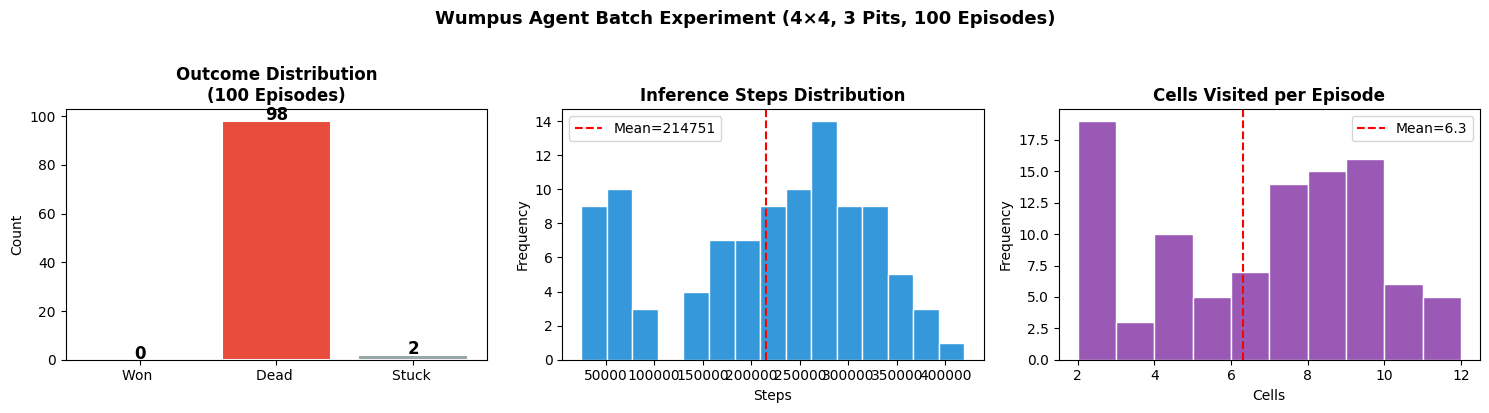

In [ ]:
def run_batch(rows=4, cols=4, num_pits=3, n_episodes=100, max_steps=50):
    results = {'won': 0, 'dead': 0, 'stuck': 0,
               'inference_steps': [], 'kb_clauses': [], 'cells_visited': []}
    for ep in range(n_episodes):
        w = WumpusWorld(rows=rows, cols=cols, num_pits=num_pits, seed=ep)
        a = WumpusAgent(w)
        for _ in range(max_steps):
            if not a.step():
                break
        if a.won:
            results['won'] += 1
        elif not a.alive:
            results['dead'] += 1
        else:
            results['stuck'] += 1
        results['inference_steps'].append(a.kb.inference_steps)
        results['kb_clauses'].append(len(a.kb.clauses))
        results['cells_visited'].append(len(a.visited))
    return results


print("Running 100 episodes... ", end="")
stats = run_batch(rows=4, cols=4, num_pits=3, n_episodes=100)
print("Done!")

n = 100
print("\n" + "=" * 45)
print("  Batch Results (100 episodes, 4×4, 3 pits)")
print("=" * 45)
print(f"  Wins   : {stats['won']:3d} / {n}  ({stats['won']}%)")
print(f"  Deaths : {stats['dead']:3d} / {n}  ({stats['dead']}%)")
print(f"  Stuck  : {stats['stuck']:3d} / {n}  ({stats['stuck']}%)")
print(f"  Avg Inference Steps : {np.mean(stats['inference_steps']):.1f}")
print(f"  Avg KB Clauses      : {np.mean(stats['kb_clauses']):.1f}")
print(f"  Avg Cells Visited   : {np.mean(stats['cells_visited']):.1f}")
print("=" * 45)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(['Won ', 'Dead ', 'Stuck '],
            [stats['won'], stats['dead'], stats['stuck']],
            color=['#2ecc71', '#e74c3c', '#95a5a6'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Outcome Distribution\n(100 Episodes)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([stats['won'], stats['dead'], stats['stuck']]):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].hist(stats['inference_steps'], bins=15, color='#3498db',
             edgecolor='white', linewidth=1)
axes[1].axvline(np.mean(stats['inference_steps']), color='red',
                linestyle='--', label=f"Mean={np.mean(stats['inference_steps']):.0f}")
axes[1].set_title('Inference Steps Distribution', fontweight='bold')
axes[1].set_xlabel('Steps')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Cells visited histogram
axes[2].hist(stats['cells_visited'], bins=10, color='#9b59b6',
             edgecolor='white', linewidth=1)
axes[2].axvline(np.mean(stats['cells_visited']), color='red',
                linestyle='--', label=f"Mean={np.mean(stats['cells_visited']):.1f}")
axes[2].set_title('Cells Visited per Episode', fontweight='bold')
axes[2].set_xlabel('Cells')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.suptitle('Wumpus Agent Batch Experiment (4×4, 3 Pits, 100 Episodes)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Cell 8 — CNF Trace: Show Resolution Proof

Demonstrate the **step-by-step resolution proof** for a specific cell's safety claim.

In [ ]:
print("=" * 60)
print("  Resolution Proof Trace Demo")
print("=" * 60)

trace_kb = PropLogicKB()

trace_kb.tell(['-P_1_0'])
trace_kb.tell(['-P_0_1'])
trace_kb.tell(['-W_1_0'])
trace_kb.tell(['-W_0_1'])

print("\nKB after visiting (0,0) with no breeze/stench:")
for i, cl in enumerate(trace_kb.clauses):
    print(f"  C{i+1}: {{ {', '.join(sorted(cl))} }}")

print("\n" + "-" * 50)
print("  ASK: Is cell (1,0) safe? → Prove: ¬P_1_0 ∧ ¬W_1_0")
print("-" * 50)

for goal in ['-P_1_0', '-W_1_0']:
    result = trace_kb.ask(goal)
    print(f"\n  Goal: [{goal}]")
    for line in result['log']:
        print(f"    {line}")
    print(f"  ► Result: {' PROVED' if result['proved'] else ' NOT PROVED'}  "
          f"({result['steps']} resolution steps)")

print("\n" + "=" * 60)
print("  Cell (1,0) is SAFE — Agent can move there.")
print("=" * 60)

  Resolution Proof Trace Demo

KB after visiting (0,0) with no breeze/stench:
  C1: { -P_0_1 }
  C2: { -W_0_1 }
  C3: { -P_1_0 }
  C4: { -W_1_0 }

--------------------------------------------------
  ASK: Is cell (1,0) safe? → Prove: ¬P_1_0 ∧ ¬W_1_0
--------------------------------------------------

  Goal: [-P_1_0]
    Goal: prove [-P_1_0]
    Negated goal clause: {P_1_0}
    Starting KB size: 5 clauses
    Step 12: CONTRADICTION ⊥ derived from {'-P_1_0'} and {'P_1_0'}
  ► Result:  PROVED  (12 resolution steps)

  Goal: [-W_1_0]
    Goal: prove [-W_1_0]
    Negated goal clause: {W_1_0}
    Starting KB size: 5 clauses
    Step 16: CONTRADICTION ⊥ derived from {'-W_1_0'} and {'W_1_0'}
  ► Result:  PROVED  (16 resolution steps)

  Cell (1,0) is SAFE — Agent can move there.


---
## Cell 9 — Custom Grid Simulation

Change parameters below and re-run to simulate your own grid.

  Custom Simulation: 5×5, 4 pits, seed=7
  World (5x5) | Pits=4
  +----+----+----+----+----+
  | .  | .  | .  | P  | .  |
  +----+----+----+----+----+
  | .  | P  | .  | .  | P  |
  +----+----+----+----+----+
  | .  | .  | .  | .  | .  |
  +----+----+----+----+----+
  | .  | P  | .  | W  | .  |
  +----+----+----+----+----+
  | .  | .  | .  | .  | .  |
  +----+----+----+----+----+


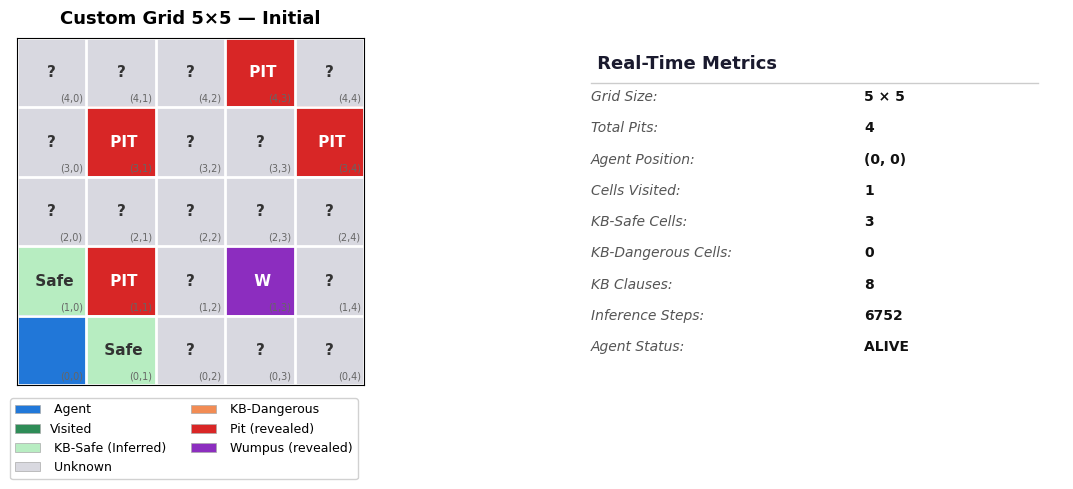

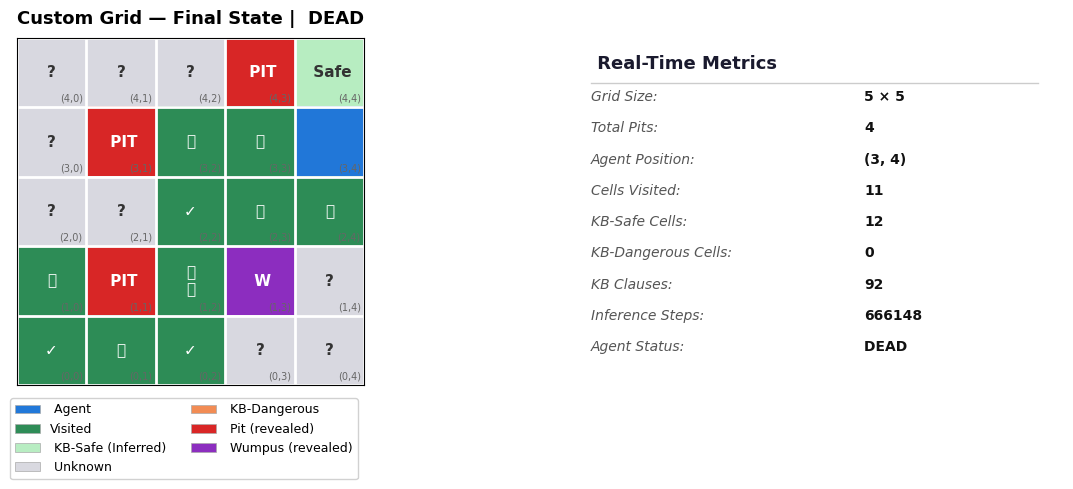


  Outcome          :  DEAD
  Inference Steps  : 666148
  KB Clauses       : 92
  Cells Visited    : 11


In [ ]:

MY_ROWS     = 5
MY_COLS     = 5
MY_PITS     = 4
MY_SEED     = 7
MY_REVEAL   = True
MY_MAX_STEPS = 30

print(f"=" * 50)
print(f"  Custom Simulation: {MY_ROWS}×{MY_COLS}, {MY_PITS} pits, seed={MY_SEED}")
print(f"=" * 50)

my_world = WumpusWorld(MY_ROWS, MY_COLS, MY_PITS, seed=MY_SEED)
my_agent = WumpusAgent(my_world)

my_world.display(reveal=True)
plot_world_state(my_world, my_agent,
                 title=f"Custom Grid {MY_ROWS}×{MY_COLS} — Initial",
                 reveal=MY_REVEAL)

for s in range(MY_MAX_STEPS):
    if not my_agent.step():
        break

status = ' WON' if my_agent.won else (' DEAD' if not my_agent.alive else ' MAX STEPS')
plot_world_state(my_world, my_agent,
                 title=f"Custom Grid — Final State | {status}",
                 reveal=True)

print(f"\n  Outcome          : {status}")
print(f"  Inference Steps  : {my_agent.kb.inference_steps}")
print(f"  KB Clauses       : {len(my_agent.kb.clauses)}")
print(f"  Cells Visited    : {len(my_agent.visited)}")